In [32]:
import pandas as pd
import numpy as np

# Objective 1 : To analyse the impact of these healthcare expenses on household poverty status.

In [55]:
# Import Data set 
# Read Excel file
df= pd.read_excel("C:\\Users\\shivraj\\OneDrive\\Desktop\\updated Hospital data.xlsx", header=0 )

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age_group                        300 non-null    object 
 1   Gender                           300 non-null    object 
 2   Household_size                   300 non-null    int64  
 3   Family_type                      300 non-null    object 
 4   Residence_area                   300 non-null    object 
 5   Occupation_of_main_earner        300 non-null    object 
 6   Highest_education_in_household   300 non-null    object 
 7   Ration_Card_type                 300 non-null    object 
 8   Type_of_hospital                 300 non-null    object 
 9   Type_of_patient                  300 non-null    object 
 10  Type_of_illness                  300 non-null    object 
 11  3_month_total_expenditure        300 non-null    int64  
 12  Household_size_numeric

In [57]:
#Poverty status 
#calculate total health expenditure  
df['Total_Health_Exp'] = (
    df['Hospital_visit_cost_numeric'] +
    df['Consultation_fee_numeric'] +
    df['Medicine_cost_numeric'] +
    df['Diagnostics_cost_numeric'] +
    df['Travel_cost_numeric'] 
)

In [58]:
# new column for per capita income 
df['PCI']=df['Monthly_income_numeric']/df['Household_size_numeric']

In [59]:
# new column for health burden ratio
df['Health_Burden_Ratio']=(df['Total_Health_Exp']/df['Monthly_income_numeric']).round(2)

In [60]:
# column for financial stress index
df['Financial_Stress_Index']=df['Lost_income_numeric']+df['Borrowed_money_numeric']+df['Financial_hardship_numeric']-df['Financial_stability_numeric']

In [61]:
df.head()

,Age_group,Gender,Household_size,Family_type,Residence_area,Occupation_of_main_earner,Highest_education_in_household,Ration_Card_type,Type_of_hospital,Type_of_patient,...,Financial_stability_numeric,Insurance_enrolled_numeric,Insurance_used_numeric,Financial_support_level_numeric,Ease_of_access_numeric,Trust_level_numeric,Total_Health_Exp,PCI,Health_Burden_Ratio,Financial_Stress_Index
0,60 and above,Female,5,Nuclear,Rural,Farming,Postgraduate,Orange,Private hospital,Outpatient,...,4,1,1,3,2,3,1651.5,3450.100000,0.10,-2
1,18–29,Male,4,Nuclear,Rural,Farming,Graduate,Orange,Private hospital,Outpatient,...,5,1,1,5,3,4,650.0,2875.000000,0.06,-3
2,45-59,Female,3,Nuclear,Rural,Farming,Graduate,Orange,Private hospital,Outpatient,...,4,1,0,0,3,3,1401.0,5750.166667,0.08,-2
3,45-59,Female,10,Joint,Rural,Farming,Graduate,Orange,Private hospital,Outpatient,...,4,0,0,0,3,2,2652.0,3450.000000,0.08,-3
4,18–29,Male,5,Nuclear,Rural,Farming,Postgraduate,Orange,Government hospital,Inpatient,...,4,1,1,4,2,3,650.0,3450.100000,0.04,-2


In [62]:
#Min-Max Scaling 
df['PCI_norm'] = 1 - (
    (df['PCI'] - df['PCI'].min()) /
    (df['PCI'].max() - df['PCI'].min())
)

In [63]:
df['Health_norm'] = (
    (df['Health_Burden_Ratio'] - df['Health_Burden_Ratio'].min()) /
    (df['Health_Burden_Ratio'].max() - df['Health_Burden_Ratio'].min())
)

df['Stress_norm'] = (
    (df['Financial_Stress_Index'] - df['Financial_Stress_Index'].min()) /
    (df['Financial_Stress_Index'].max() - df['Financial_Stress_Index'].min())
)

In [64]:
df.head()

,Age_group,Gender,Household_size,Family_type,Residence_area,Occupation_of_main_earner,Highest_education_in_household,Ration_Card_type,Type_of_hospital,Type_of_patient,...,Financial_support_level_numeric,Ease_of_access_numeric,Trust_level_numeric,Total_Health_Exp,PCI,Health_Burden_Ratio,Financial_Stress_Index,PCI_norm,Health_norm,Stress_norm
0,60 and above,Female,5,Nuclear,Rural,Farming,Postgraduate,Orange,Private hospital,Outpatient,...,3,2,3,1651.5,3450.100000,0.10,-2,0.904108,0.073394,0.2
1,18–29,Male,4,Nuclear,Rural,Farming,Graduate,Orange,Private hospital,Outpatient,...,5,3,4,650.0,2875.000000,0.06,-3,0.924659,0.036697,0.1
2,45-59,Female,3,Nuclear,Rural,Farming,Graduate,Orange,Private hospital,Outpatient,...,0,3,3,1401.0,5750.166667,0.08,-2,0.821915,0.055046,0.2
3,45-59,Female,10,Joint,Rural,Farming,Graduate,Orange,Private hospital,Outpatient,...,0,3,2,2652.0,3450.000000,0.08,-3,0.904111,0.055046,0.1
4,18–29,Male,5,Nuclear,Rural,Farming,Postgraduate,Orange,Government hospital,Inpatient,...,4,2,3,650.0,3450.100000,0.04,-2,0.904108,0.018349,0.2


In [65]:
#poverty score 
df['Poverty_Score'] = (
    0.5 * df['PCI_norm'] +
    0.3 * df['Health_norm'] +
    0.2 * df['Stress_norm']
)

In [66]:
# function for classification of poor and non poor 
def classify(x):
    if x >= 0.5:
        return 'Poor'
    else:
        return 'Non-poor'

df['Poverty_Status'] = df['Poverty_Score'].apply(classify)

In [45]:
df.sample(10)

,Age_group,Gender,Household_size,Family_type,Residence_area,Occupation_of_main_earner,Highest_education_in_household,Ration_Card_type,Type_of_hospital,Type_of_patient,...,Trust_level_numeric,Total_Health_Exp,PCI,Health_Burden_Ratio,Financial_Stress_Index,PCI_norm,Health_norm,Stress_norm,Poverty_Score,Poverty_Status
63,18–29,Female,4,Nuclear,Rural,Farming,Graduate,Orange,Private hospital,Outpatient,...,2.0,8251.5,8625.00,0.24,0.0,0.719183,0.201835,0.4,0.500142,Poor
196,45-59,Female,6,Nuclear,Urban,Private Service,Secondary,Orange,Private hospital,Inpatient,...,4.0,4902.0,4791.75,0.17,-2.0,0.856164,0.137615,0.2,0.509366,Poor
8,30-44,Female,4,Nuclear,Rural,Government Service,Postgraduate,White,Government hospital,Outpatient,...,3.0,650.0,8625.00,0.02,-3.0,0.719183,0.000000,0.1,0.379592,Non-poor
105,60 and above,Female,5,Nuclear,Rural,Private Service,Graduate,Orange,Government hospital,Outpatient,...,2.0,2401.5,3450.10,0.14,-3.0,0.904108,0.110092,0.1,0.505081,Poor
288,18–29,Female,5,Nuclear,Rural,Private Service,Graduate,Orange,Government hospital,Outpatient,...,5.0,650.0,5750.10,0.02,-4.0,0.821917,0.000000,0.0,0.410959,Non-poor
86,30-44,Female,10,Joint,Rural,Farming,Graduate,Orange,Private hospital,Inpatient,...,3.0,6502.5,1725.05,0.38,1.0,0.965752,0.330275,0.5,0.681959,Poor
168,18–29,Female,6,Nuclear,Urban,Private Service,Postgraduate,White,Private hospital,Inpatient,...,3.0,4902.0,5750.00,0.14,-4.0,0.821921,0.110092,0.0,0.443988,Non-poor
119,45-59,Female,5,Nuclear,Urban,Government Service,Graduate,White,Private hospital,Inpatient,...,2.0,7852.5,6900.00,0.23,-3.0,0.780826,0.192661,0.1,0.468211,Non-poor
202,45-59,Male,6,Nuclear,Urban,Private Service,Graduate,Orange,Government hospital,Inpatient,...,5.0,1150.5,4791.75,0.04,-4.0,0.856164,0.018349,0.0,0.433587,Non-poor
189,60 and above,Female,8,Joint,Rural,Farming,Secondary,Orange,Private hospital,Inpatient,...,5.0,5352.0,4312.50,0.16,-4.0,0.873290,0.128440,0.0,0.475177,Non-poor


In [30]:
df.to_excel("Hospital num data.xlsx", index=False)

NameError: name 'final_df' is not defined

In [67]:
#Ratio of poverty
print((df['Poverty_Status'].value_counts()[1]/df['Poverty_Status'].shape[0])*100)

22.333333333333332


C:\Users\shivraj\AppData\Local\Temp\ipykernel_14584\2328200099.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print((df['Poverty_Status'].value_counts()[1]/df['Poverty_Status'].shape[0])*100)


In [68]:
# Filter only Inpatient data
inpatient_df = df[df['Type_of_patient'] == 'Inpatient']

# Count
counts = inpatient_df['Poverty_Status'].value_counts()

# Ratio (percentage)
ratio = inpatient_df['Poverty_Status'].value_counts(normalize=True) * 100

print("Counts:\n", counts)
print("\nRatio (%):\n", ratio)

Counts:
 Poverty_Status
Non-poor    138
Poor         47
Name: count, dtype: int64

Ratio (%):
 Poverty_Status
Non-poor    74.594595
Poor        25.405405
Name: proportion, dtype: float64


In [54]:
# Filter only outpatient data
inpatient_df = df[df['Type_of_patient'] == 'Outpatient']

# Count
counts = inpatient_df['Poverty_Status'].value_counts()

# Ratio (percentage)
ratio = inpatient_df['Poverty_Status'].value_counts(normalize=True) * 100

print("Counts:\n", counts)
print("\nRatio (%):\n", ratio)

Counts:
 Poverty_Status
Non-poor    95
Poor        20
Name: count, dtype: int64

Ratio (%):
 Poverty_Status
Non-poor    82.608696
Poor        17.391304
Name: proportion, dtype: float64


In [69]:
# Filter by Hospital Type
hospital_df = df.groupby('Type_of_hospital')

for name, group in hospital_df:
    print(f"\nHospital Type: {name}")
    
    counts = group['Poverty_Status'].value_counts()
    ratio = group['Poverty_Status'].value_counts(normalize=True) * 100
    
    print("Counts:\n", counts)
    print("Ratio (%):\n", ratio)


Hospital Type: Government hospital
Counts:
 Poverty_Status
Non-poor    117
Poor         29
Name: count, dtype: int64
Ratio (%):
 Poverty_Status
Non-poor    80.136986
Poor        19.863014
Name: proportion, dtype: float64

Hospital Type: Private hospital
Counts:
 Poverty_Status
Non-poor    116
Poor         38
Name: count, dtype: int64
Ratio (%):
 Poverty_Status
Non-poor    75.324675
Poor        24.675325
Name: proportion, dtype: float64


In [70]:
# Filter by Residence Area
residence_df = df.groupby('Residence_area')

for name, group in residence_df:
    print(f"\nResidence Area: {name}")
    
    counts = group['Poverty_Status'].value_counts()
    ratio = group['Poverty_Status'].value_counts(normalize=True) * 100
    
    print("Counts:\n", counts)
    print("Ratio (%):\n", ratio)


Residence Area: Rural
Counts:
 Poverty_Status
Non-poor    101
Poor         29
Name: count, dtype: int64
Ratio (%):
 Poverty_Status
Non-poor    77.692308
Poor        22.307692
Name: proportion, dtype: float64

Residence Area: Urban
Counts:
 Poverty_Status
Non-poor    132
Poor         38
Name: count, dtype: int64
Ratio (%):
 Poverty_Status
Non-poor    77.647059
Poor        22.352941
Name: proportion, dtype: float64


# Objective 2 :  To examine the factors affecting out-of-pocket healthcare expenses in Kolhapur city, including both medical and non-medical costs.


In [72]:
# Medical cost
df['medical_cost'] = df['Hospital_visit_cost_numeric'] + df['Consultation_fee_numeric'] + \
                     df['Medicine_cost_numeric'] + df['Diagnostics_cost_numeric']

# Non-medical cost
df['non_medical_cost'] = df['Travel_cost_numeric'] + df['Lost_income_numeric']

In [73]:
#Descriptive Statistics
df[['medical_cost','non_medical_cost','Total_Health_Exp','Health_Burden_Ratio']].describe()

,medical_cost,non_medical_cost,Total_Health_Exp,Health_Burden_Ratio
count,300.000000,300.000000,300.000000,300.000000
mean,2395.238333,216.298333,2611.300000,0.094333
std,2452.045392,224.500565,2621.813267,0.110801
min,550.000000,50.000000,600.000000,0.020000
25%,600.000000,50.000000,650.000000,0.030000
50%,1100.500000,51.000000,1401.000000,0.050000
75%,3601.000000,300.500000,3901.500000,0.140000
max,12000.000000,1001.000000,13000.000000,1.110000


In [74]:
#Mean Comparison (Factors)
print("\nMean total OOP by Residence Area:")
print(df.groupby('Residence_area')['Total_Health_Exp'].mean())

print("\nMean total OOP by Gender:")
print(df.groupby('Gender')['Total_Health_Exp'].mean())

print("\nMean total OOP by Family Type:")
print(df.groupby('Family_type')['Total_Health_Exp'].mean())

print("\nMean total OOP by Type of Hospital:")
print(df.groupby('Type_of_hospital')['Total_Health_Exp'].mean())

print("\nMean total OOP by Type of Patient:")
print(df.groupby('Type_of_patient')['Total_Health_Exp'].mean())


Mean total OOP by Residence Area:
Residence_area
Rural    2388.946154
Urban    2781.335294
Name: Total_Health_Exp, dtype: float64

Mean total OOP by Gender:
Gender
Female    2492.002976
Male      2763.132576
Name: Total_Health_Exp, dtype: float64

Mean total OOP by Family Type:
Family_type
Joint      3956.115385
Nuclear    2329.322581
Name: Total_Health_Exp, dtype: float64

Mean total OOP by Type of Hospital:
Type_of_hospital
Government hospital    1253.212329
Private hospital       3898.837662
Name: Total_Health_Exp, dtype: float64

Mean total OOP by Type of Patient:
Type_of_patient
Inpatient     3281.418919
Outpatient    1533.282609
Name: Total_Health_Exp, dtype: float64


In [43]:
#T-test (Insurance Effect)
from scipy.stats import ttest_ind

insured = final_df1[final_df1['Insurance_enrolled_numeric']==1]['Total_Health_Exp']
not_insured = final_df1[final_df1['Insurance_enrolled_numeric']==0]['Total_Health_Exp']

t_stat, p_value = ttest_ind(insured, not_insured, equal_var=False)

print("\nT-test: Total OOP by Insurance Enrollment")
print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Result: Significant difference between insured and non-insured")
else:
    print("Result: No significant difference")


T-test: Total OOP by Insurance Enrollment
T-statistic: -3.4096
P-value: 0.0012
Result: Significant difference between insured and non-insured


In [75]:
#ANOVA (Multiple Categories)
from scipy.stats import f_oneway

# ANOVA for Residence Area
groups_res = [g['Total_Health_Exp'].dropna() for _, g in df.groupby('Residence_area')]
f_stat_res, p_val_res = f_oneway(*groups_res)

print("\nANOVA: Total OOP by Residence Area")
print("F-statistic:", round(f_stat_res, 4))
print("P-value:", round(p_val_res, 4))


# ANOVA for Type of Hospital
groups_hosp = [g['Total_Health_Exp'].dropna() for _, g in df.groupby('Type_of_hospital')]
f_stat_hosp, p_val_hosp = f_oneway(*groups_hosp)

print("\nANOVA: Total OOP by Type of Hospital")
print("F-statistic:", round(f_stat_hosp, 4))
print("P-value:", round(p_val_hosp, 4))

if p_val_res < 0.05:
    print("Result: Significant difference across Residence Area")
else:
    print("Result: No significant difference across Residence Area")

if p_val_hosp < 0.05:
    print("Result: Significant difference across Hospital Type")
else:
    print("Result: No significant difference across Hospital Type")



ANOVA: Total OOP by Residence Area
F-statistic: 1.6537
P-value: 0.1995

ANOVA: Total OOP by Type of Hospital
F-statistic: 102.1243
P-value: 0.0
Result: No significant difference across Residence Area
Result: Significant difference across Hospital Type


In [77]:
#check multicollinearity in variables 
X = df[[
    'Household_size',
    'Visits_per_month_numeric',
    'Monthly_income_numeric',
    'Lost_income_numeric',
    'Borrowed_money_numeric',
    'Insurance_enrolled_numeric',
    'Financial_hardship_numeric',
    'Financial_stability_numeric',
    'Gender',
    'Residence_area',
    'Family_type',
    'Type_of_hospital',
    'Type_of_patient'
]].dropna()

In [78]:
#Convert categorical → dummy variables
X = pd.get_dummies(X, drop_first=True)

In [79]:
#convert data type 
X = X.apply(lambda col: pd.to_numeric(col, errors='coerce'))
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
X = X.astype(float)

In [80]:
# Calculate VIF 
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

                             Variable        VIF
7         Financial_stability_numeric  42.683478
2              Monthly_income_numeric  29.184495
0                      Household_size  19.020382
10                Family_type_Nuclear  10.825315
6          Financial_hardship_numeric   8.586071
5          Insurance_enrolled_numeric   8.459081
9                Residence_area_Urban   3.285170
11  Type_of_hospital_Private hospital   2.651592
1            Visits_per_month_numeric   2.594656
12         Type_of_patient_Outpatient   2.176963
4              Borrowed_money_numeric   1.850774
8                         Gender_Male   1.849836
3                 Lost_income_numeric   1.832964


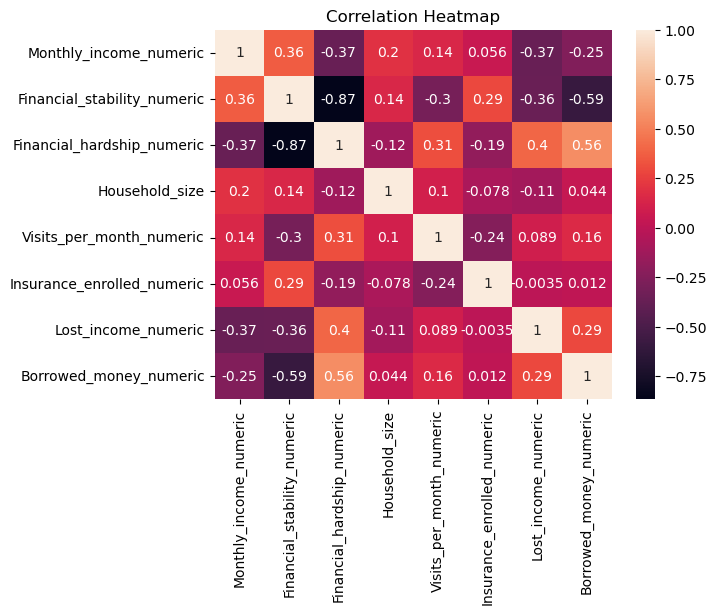

In [81]:
#Visulization of correlation 
#Step 1: Select your variables
cols = [
    'Monthly_income_numeric','Financial_stability_numeric','Financial_hardship_numeric',
    'Household_size','Visits_per_month_numeric','Insurance_enrolled_numeric','Lost_income_numeric','Borrowed_money_numeric'
]

corr_data = df[cols].dropna()

#Step 2: Compute correlation
corr_matrix = corr_data.corr()

#Step 3: Plot Heatmap (Seaborn)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(corr_matrix, annot=True)

plt.title("Correlation Heatmap")
plt.show()

In [82]:
# ridge regression 
#Step 1: Prepare Data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Select variables
X_num = df[[
    'Household_size','Visits_per_month_numeric','Monthly_income_numeric',
    'Lost_income_numeric','Borrowed_money_numeric','Insurance_enrolled_numeric',
    'Financial_hardship_numeric','Financial_stability_numeric'
]]

# Convert categorical to dummy
X_cat = pd.get_dummies(df[[
    'Gender','Residence_area','Family_type','Type_of_hospital','Type_of_patient'
]], drop_first=True)

x=pd.concat([X_num,X_cat],axis=1)


y = df['Total_Health_Exp']

In [83]:
#Step 2: Standardize Data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)



In [84]:
#Step 3: Apply Ridge Regression
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(x_scaled, y)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [85]:
#Step 4: Check Coefficients

coefficients = pd.DataFrame({
    "Variable": x.columns,
    "Coefficient": model.coef_
})

print(coefficients.sort_values(by="Coefficient", ascending=False))

                             Variable  Coefficient
11  Type_of_hospital_Private hospital   911.585577
4              Borrowed_money_numeric   663.007443
1            Visits_per_month_numeric   489.398255
2              Monthly_income_numeric   463.178084
0                      Household_size   351.449984
6          Financial_hardship_numeric   120.716630
8                         Gender_Male    99.656778
3                 Lost_income_numeric    97.344290
9                Residence_area_Urban   -31.037273
10                Family_type_Nuclear   -32.766194
7         Financial_stability_numeric  -137.906262
5          Insurance_enrolled_numeric  -243.540975
12         Type_of_patient_Outpatient  -696.295302


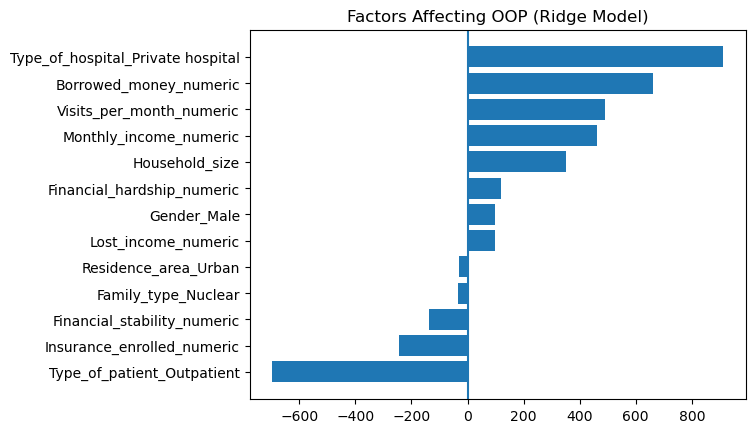

In [86]:
# visulization of ridge reg result 

import matplotlib.pyplot as plt

# Sort data
coef_df = coefficients.sort_values(by="Coefficient")


plt.figure()
plt.barh(coef_df["Variable"], coef_df["Coefficient"])

# Add vertical line at 0
plt.axvline(0)

plt.title("Factors Affecting OOP (Ridge Model)")
plt.show()

# Objective 3: 	To compare healthcare spending and poverty across different family types, insurance coverage and urban/rural households.

In [87]:
#MODEL 1: Compare Healthcare Spending
#Method: Two-way ANOVA / Factorial ANOVA

import statsmodels.api as sm
from statsmodels.formula.api import ols

model_anova = ols(
    'Total_Health_Exp ~ C(Family_type) + C(Insurance_enrolled_numeric) + C(Residence_area) + '
    'C(Family_type):C(Insurance_enrolled_numeric) + C(Family_type):C(Residence_area)',
    data=df
).fit()

anova_table = sm.stats.anova_lm(model_anova, typ=2)
print(anova_table)

                                                    sum_sq     df          F  \
C(Family_type)                                1.020492e+08    1.0  16.760249   
C(Insurance_enrolled_numeric)                 9.870832e+07    1.0  16.211555   
C(Residence_area)                             5.881579e+07    1.0   9.659727   
C(Family_type):C(Insurance_enrolled_numeric)  8.626362e+06    1.0   1.416768   
C(Family_type):C(Residence_area)              1.094247e+07    1.0   1.797159   
Residual                                      1.790096e+09  294.0        NaN   

                                                PR(>F)  
C(Family_type)                                0.000055  
C(Insurance_enrolled_numeric)                 0.000072  
C(Residence_area)                             0.002068  
C(Family_type):C(Insurance_enrolled_numeric)  0.234896  
C(Family_type):C(Residence_area)              0.181091  
Residual                                           NaN  


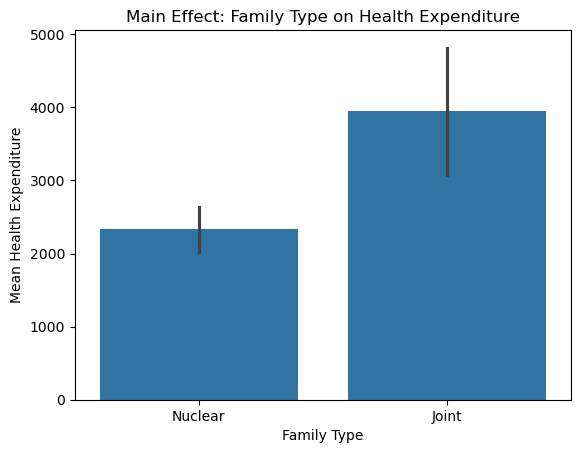

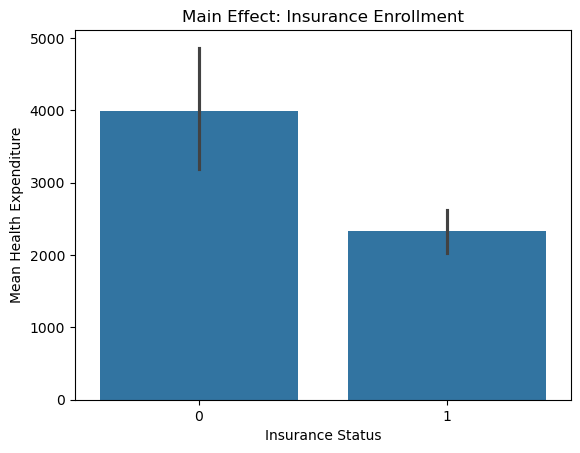

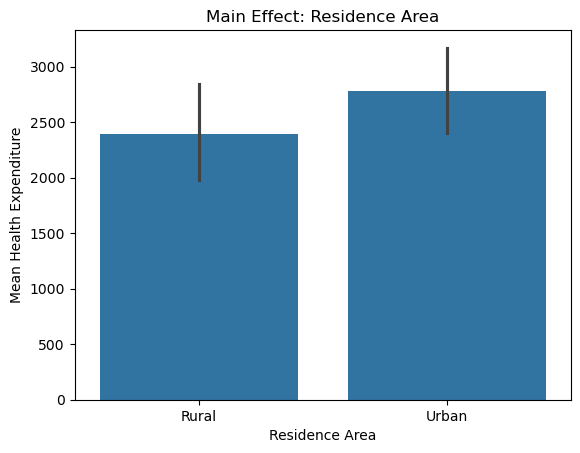

In [88]:
# graphical presentation
#Main Effects Plots

# Family Type
plt.figure()
sns.barplot(data=df, x='Family_type', y='Total_Health_Exp')
plt.title('Main Effect: Family Type on Health Expenditure')
plt.xlabel('Family Type')
plt.ylabel('Mean Health Expenditure')
plt.show()


# Insurance Enrollment
plt.figure()
sns.barplot(data=df, x='Insurance_enrolled_numeric', y='Total_Health_Exp')
plt.title('Main Effect: Insurance Enrollment')
plt.xlabel('Insurance Status')
plt.ylabel('Mean Health Expenditure')
plt.show()


# Residence Area
plt.figure()
sns.barplot(data=df, x='Residence_area', y='Total_Health_Exp')
plt.title('Main Effect: Residence Area')
plt.xlabel('Residence Area')
plt.ylabel('Mean Health Expenditure')
plt.show()

In [90]:
#Combine both → Multivariate Analysis (MANOVA)

from statsmodels.multivariate.manova import MANOVA

manova = MANOVA.from_formula(
    'Total_Health_Exp + Poverty_Status ~ C(Family_type) + C(Insurance_enrolled_numeric) + C(Residence_area)',
    data=df
)

print(manova.mv_test())

                     Multivariate linear model
                                                                    
---------------------------------------------------------------------
          Intercept         Value   Num DF   Den DF   F Value  Pr > F
---------------------------------------------------------------------
             Wilks' lambda  0.6829  2.0000  295.0000  68.4853  0.0000
            Pillai's trace  0.3171  2.0000  295.0000  68.4853  0.0000
    Hotelling-Lawley trace  0.4643  2.0000  295.0000  68.4853  0.0000
       Roy's greatest root  0.4643  2.0000  295.0000  68.4853  0.0000
--------------------------------------------------------------------
                                                                    
---------------------------------------------------------------------
        C(Family_type)      Value   Num DF   Den DF   F Value  Pr > F
---------------------------------------------------------------------
             Wilks' lambda  0.9258  2.0000  29

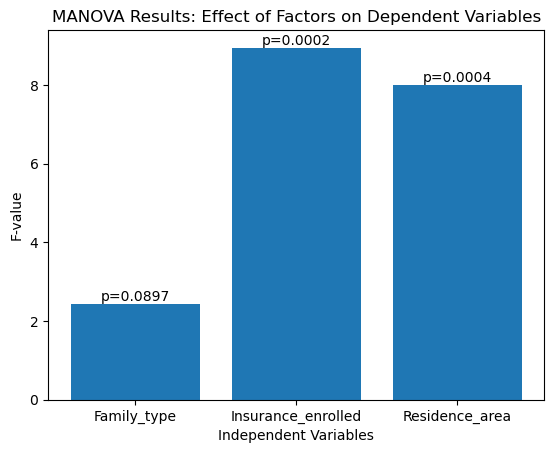

In [91]:
#bar plot

import matplotlib.pyplot as plt

# Data from your MANOVA output
variables = ['Family_type', 'Insurance_enrolled', 'Residence_area']
f_values = [2.4338, 8.9502, 8.0069]
p_values = [0.0897, 0.0002, 0.0004]

# Create bar plot
plt.figure()
plt.bar(variables, f_values)

# Add p-value labels on top of bars
for i in range(len(variables)):
    plt.text(i, f_values[i], f'p={p_values[i]:.4f}', 
             ha='center', va='bottom')

# Labels and title
plt.xlabel('Independent Variables')
plt.ylabel('F-value')
plt.title('MANOVA Results: Effect of Factors on Dependent Variables')

# Show plot
plt.show()

# Objective 4 : 4.	To assess patient awareness and use of insurance and government schemes for both outpatient and inpatient care.

In [92]:
from scipy.stats import chi2_contingency

# Insurance enrolled vs Insurance used
table = pd.crosstab(df['Insurance_enrolled_numeric'], df['Insurance_used_numeric'])
chi2, p, dof, exp = chi2_contingency(table)

print("Chi-square:", chi2)
print("P-value:", p)

# Interpretation
alpha = 0.05
print("\n===== Interpretation =====")
if p < alpha:
    print("Reject H0: There is a significant association between Insurance Enrollment and Usage.")
else:
    print("Fail to reject H0: No significant association between Insurance Enrollment and Usage.")

Chi-square: 73.66071428571428
P-value: 9.27669352031276e-18

===== Interpretation =====
Reject H0: There is a significant association between Insurance Enrollment and Usage.


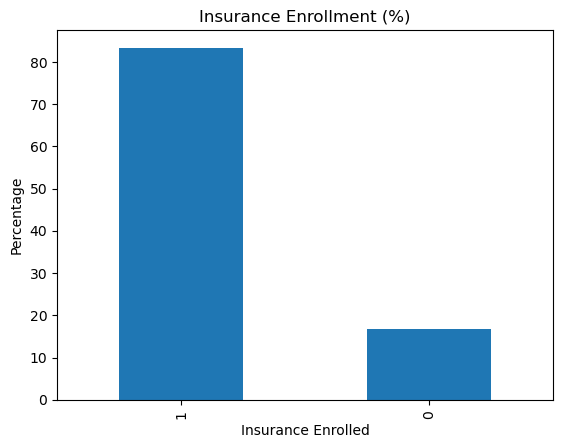

In [66]:
#bar graph for insurance enrollment 

counts =final_df1['Insurance_enrolled_numeric'].value_counts(normalize=True) * 100

plt.figure()
counts.plot(kind='bar')

plt.title("Insurance Enrollment (%)")
plt.xlabel("Insurance Enrolled")
plt.ylabel("Percentage")

plt.show()